# EDA — Skin & Acne Dataset
**Capstone Project: DerMind — Platform Kesehatan Digital Berbasis AI**

Dataset yang digunakan:
- `master_skin_image_manifest.csv` — 20.015 gambar dari DermNet, AcneDataset, SkinDefects
- `HAM10000_clean.csv` — 10.015 metadata lesi kulit klinis (7 kelas)

**Pertanyaan Bisnis yang dijawab:**
- PB3: Kondisi kulit apa yang paling umum ditemukan dalam dataset dan bagaimana distribusinya?
- PB4: Apakah faktor demografis (usia, lokasi tubuh) berkorelasi dengan jenis kondisi kulit?


## 1. Import Library & Load Data

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── DerMind color palette ──────────────────────────────────
TEAL    = '#14B8A6'
CYAN    = '#06B6D4'
BG_DARK = '#0F172A'
BG_CARD = '#1E293B'
TEXT_CLR= '#F1F5F9'
PALETTE = ['#14B8A6','#06B6D4','#3B82F6','#8B5CF6','#F59E0B','#EF4444','#10B981',
           '#F97316','#EC4899','#84CC16','#A78BFA']

plt.rcParams.update({
    'figure.facecolor': BG_DARK, 'axes.facecolor': BG_CARD,
    'axes.edgecolor': '#334155', 'axes.labelcolor': TEXT_CLR,
    'xtick.color': TEXT_CLR, 'ytick.color': TEXT_CLR,
    'text.color': TEXT_CLR, 'grid.color': '#334155',
    'figure.dpi': 120, 'font.size': 10,
})

df_skin = pd.read_csv('master_skin_image_manifest.csv')
df_ham  = pd.read_csv('HAM10000_clean.csv')

print(f'Skin manifest shape: {df_skin.shape}')
print(f'HAM10000 shape     : {df_ham.shape}')
print()
print('Skin columns:', list(df_skin.columns))
print('HAM10000 columns:', list(df_ham.columns))

Skin manifest shape: (20015, 4)
HAM10000 shape     : (10015, 9)

Skin columns: ['filename', 'filepath', 'label', 'source']
HAM10000 columns: ['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization', 'dx_full', 'is_duplicate_lesion']


## 2. Distribusi Kelas (PB3)

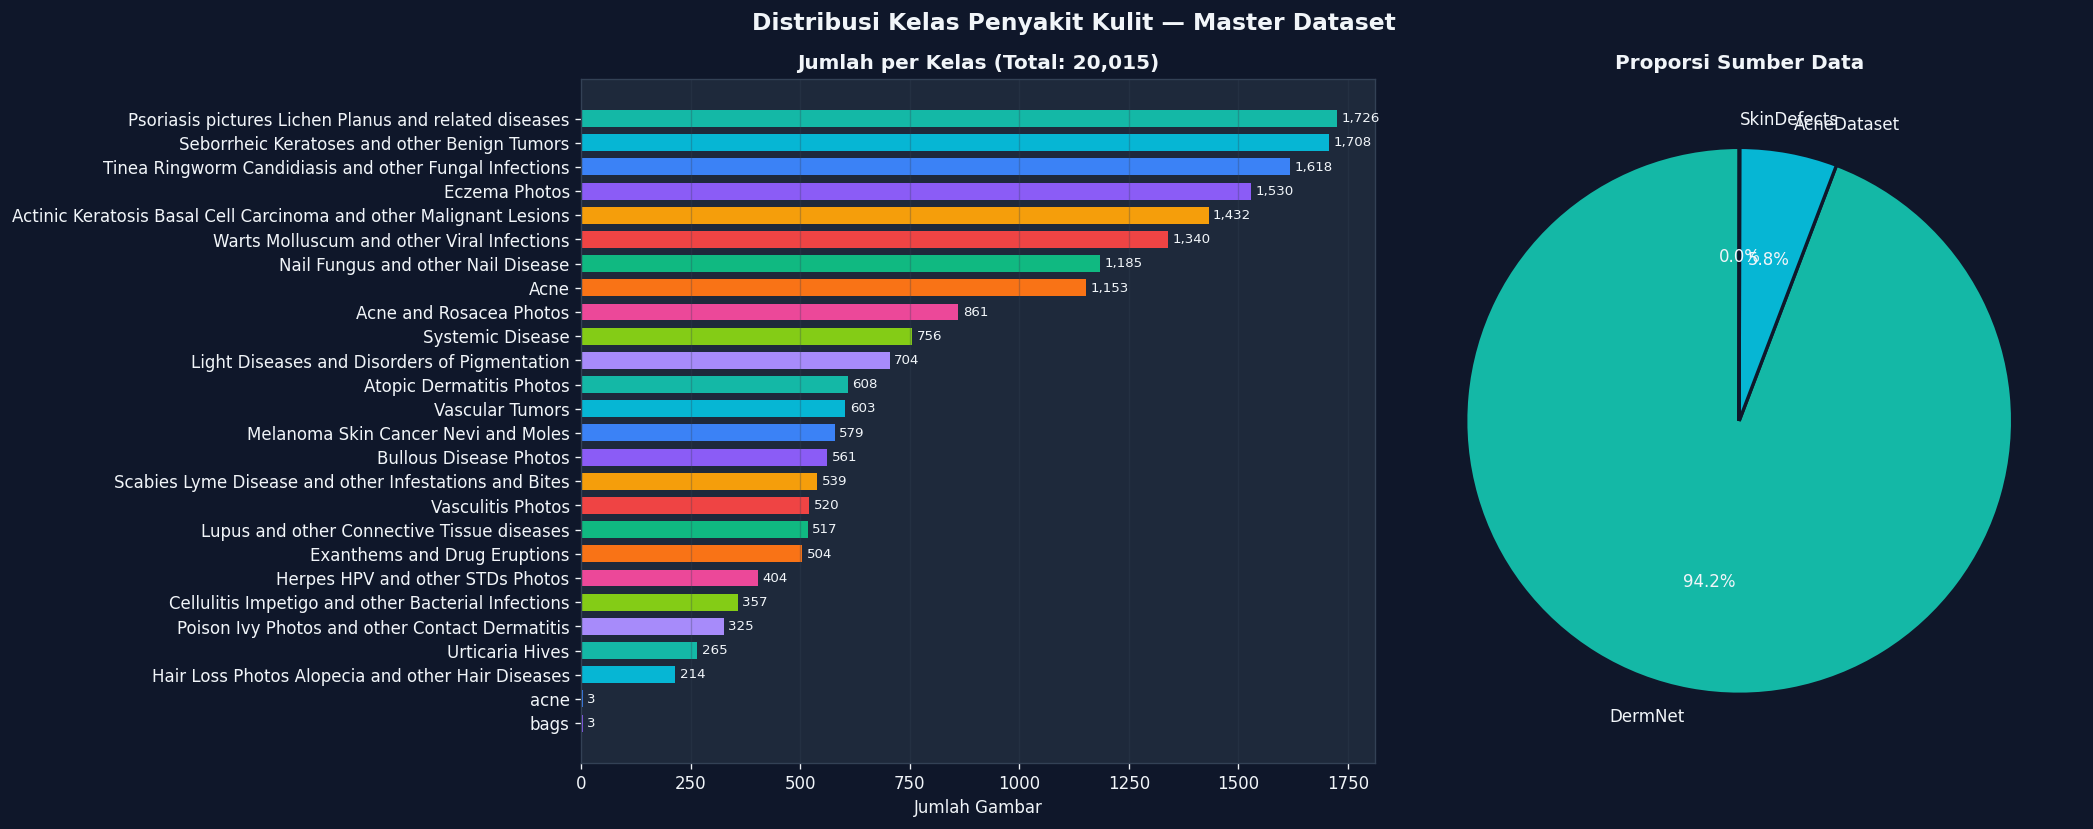

Imbalance ratio: 575.3:1


In [7]:
vc_skin = df_skin['label'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Distribusi Kelas Penyakit Kulit — Master Dataset', fontsize=14, fontweight='bold', color=TEXT_CLR)

# Horizontal bar
colors_bar = PALETTE[:len(vc_skin)]
bars = axes[0].barh(vc_skin.index, vc_skin.values, color=colors_bar, edgecolor='none', height=0.7)
for bar, val in zip(bars, vc_skin.values):
    axes[0].text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
                  f'{val:,}', va='center', fontsize=8, color=TEXT_CLR)
axes[0].set_xlabel('Jumlah Gambar', color=TEXT_CLR)
axes[0].set_title(f'Jumlah per Kelas (Total: {len(df_skin):,})', color=TEXT_CLR, fontweight='bold')
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)

# Distribusi per sumber
source_vc = df_skin['source'].value_counts()
wedges, texts, autotexts = axes[1].pie(
    source_vc.values, labels=source_vc.index, autopct='%1.1f%%',
    colors=[TEAL, CYAN, '#8B5CF6'], startangle=90,
    wedgeprops={'edgecolor': BG_DARK, 'linewidth': 2}
)
for t in texts + autotexts: t.set_color(TEXT_CLR)
axes[1].set_title('Proporsi Sumber Data', color=TEXT_CLR, fontweight='bold')

plt.tight_layout()
plt.savefig('eda_skin_01_distribusi_kelas.png', bbox_inches='tight', facecolor=BG_DARK)
plt.show()
print(f'Imbalance ratio: {vc_skin.max()/vc_skin.min():.1f}:1')

> **Insight PB3:** Dataset skin didominasi oleh **Psoriasis** (8.6%) dan **Seborrheic Keratoses** (8.5%). 94.2% data berasal dari DermNet, sisanya Acne Dataset dan SkinDefects. Imbalance ratio cukup tinggi — augmentasi data diperlukan untuk kelas minority saat training model CNN.

## 3. HAM10000 — Distribusi Klinis

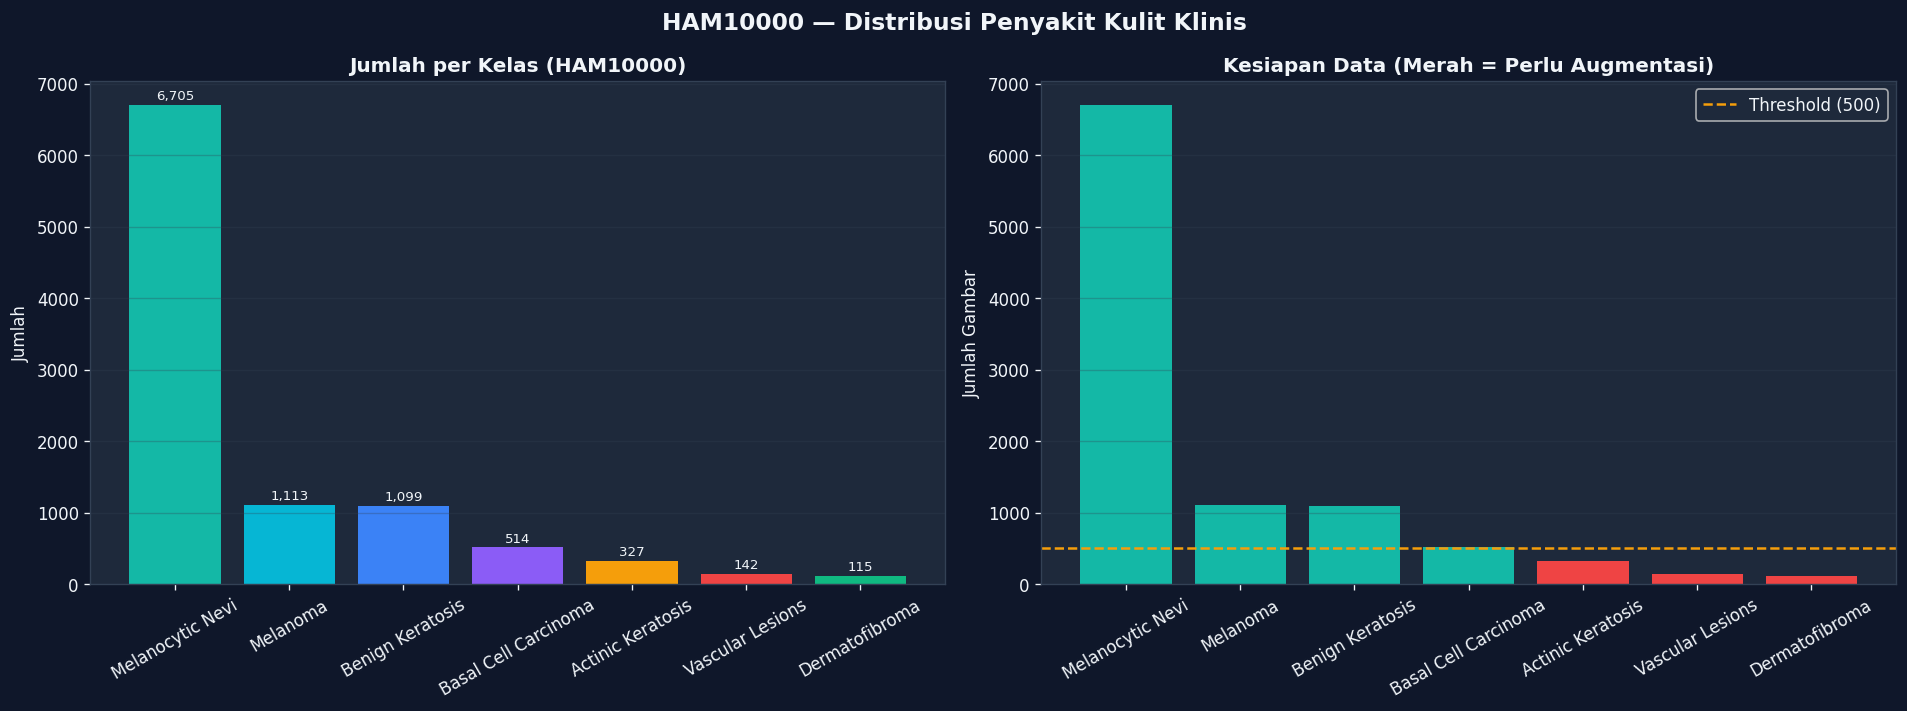

In [8]:
dx_map = {
    'nv': 'Melanocytic Nevi', 'mel': 'Melanoma', 'bkl': 'Benign Keratosis',
    'bcc': 'Basal Cell Carcinoma', 'akiec': 'Actinic Keratosis',
    'vasc': 'Vascular Lesions', 'df': 'Dermatofibroma'
}
df_ham['dx_full2'] = df_ham['dx'].map(dx_map)

vc_ham = df_ham['dx'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('HAM10000 — Distribusi Penyakit Kulit Klinis', fontsize=14, fontweight='bold', color=TEXT_CLR)

# Bar
labels_ham = [dx_map[k] for k in vc_ham.index]
bars = axes[0].bar(labels_ham, vc_ham.values, color=PALETTE[:7], edgecolor='none')
for bar, val in zip(bars, vc_ham.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                  f'{val:,}', ha='center', va='bottom', fontsize=8, color=TEXT_CLR)
axes[0].set_title('Jumlah per Kelas (HAM10000)', color=TEXT_CLR, fontweight='bold')
axes[0].set_ylabel('Jumlah', color=TEXT_CLR)
axes[0].tick_params(axis='x', rotation=30)
axes[0].grid(axis='y', alpha=0.3)

# Threshold augmentation check
threshold_ok = 500
colors_thresh = [TEAL if v >= threshold_ok else '#EF4444' for v in vc_ham.values]
axes[1].bar(labels_ham, vc_ham.values, color=colors_thresh, edgecolor='none')
axes[1].axhline(threshold_ok, color='#F59E0B', linestyle='--', linewidth=1.5, label=f'Threshold ({threshold_ok})')
axes[1].set_title('Kesiapan Data (Merah = Perlu Augmentasi)', color=TEXT_CLR, fontweight='bold')
axes[1].set_ylabel('Jumlah Gambar', color=TEXT_CLR)
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('eda_skin_02_ham10000.png', bbox_inches='tight', facecolor=BG_DARK)
plt.show()

## 4. Analisis Demografis — Usia & Gender (PB4)

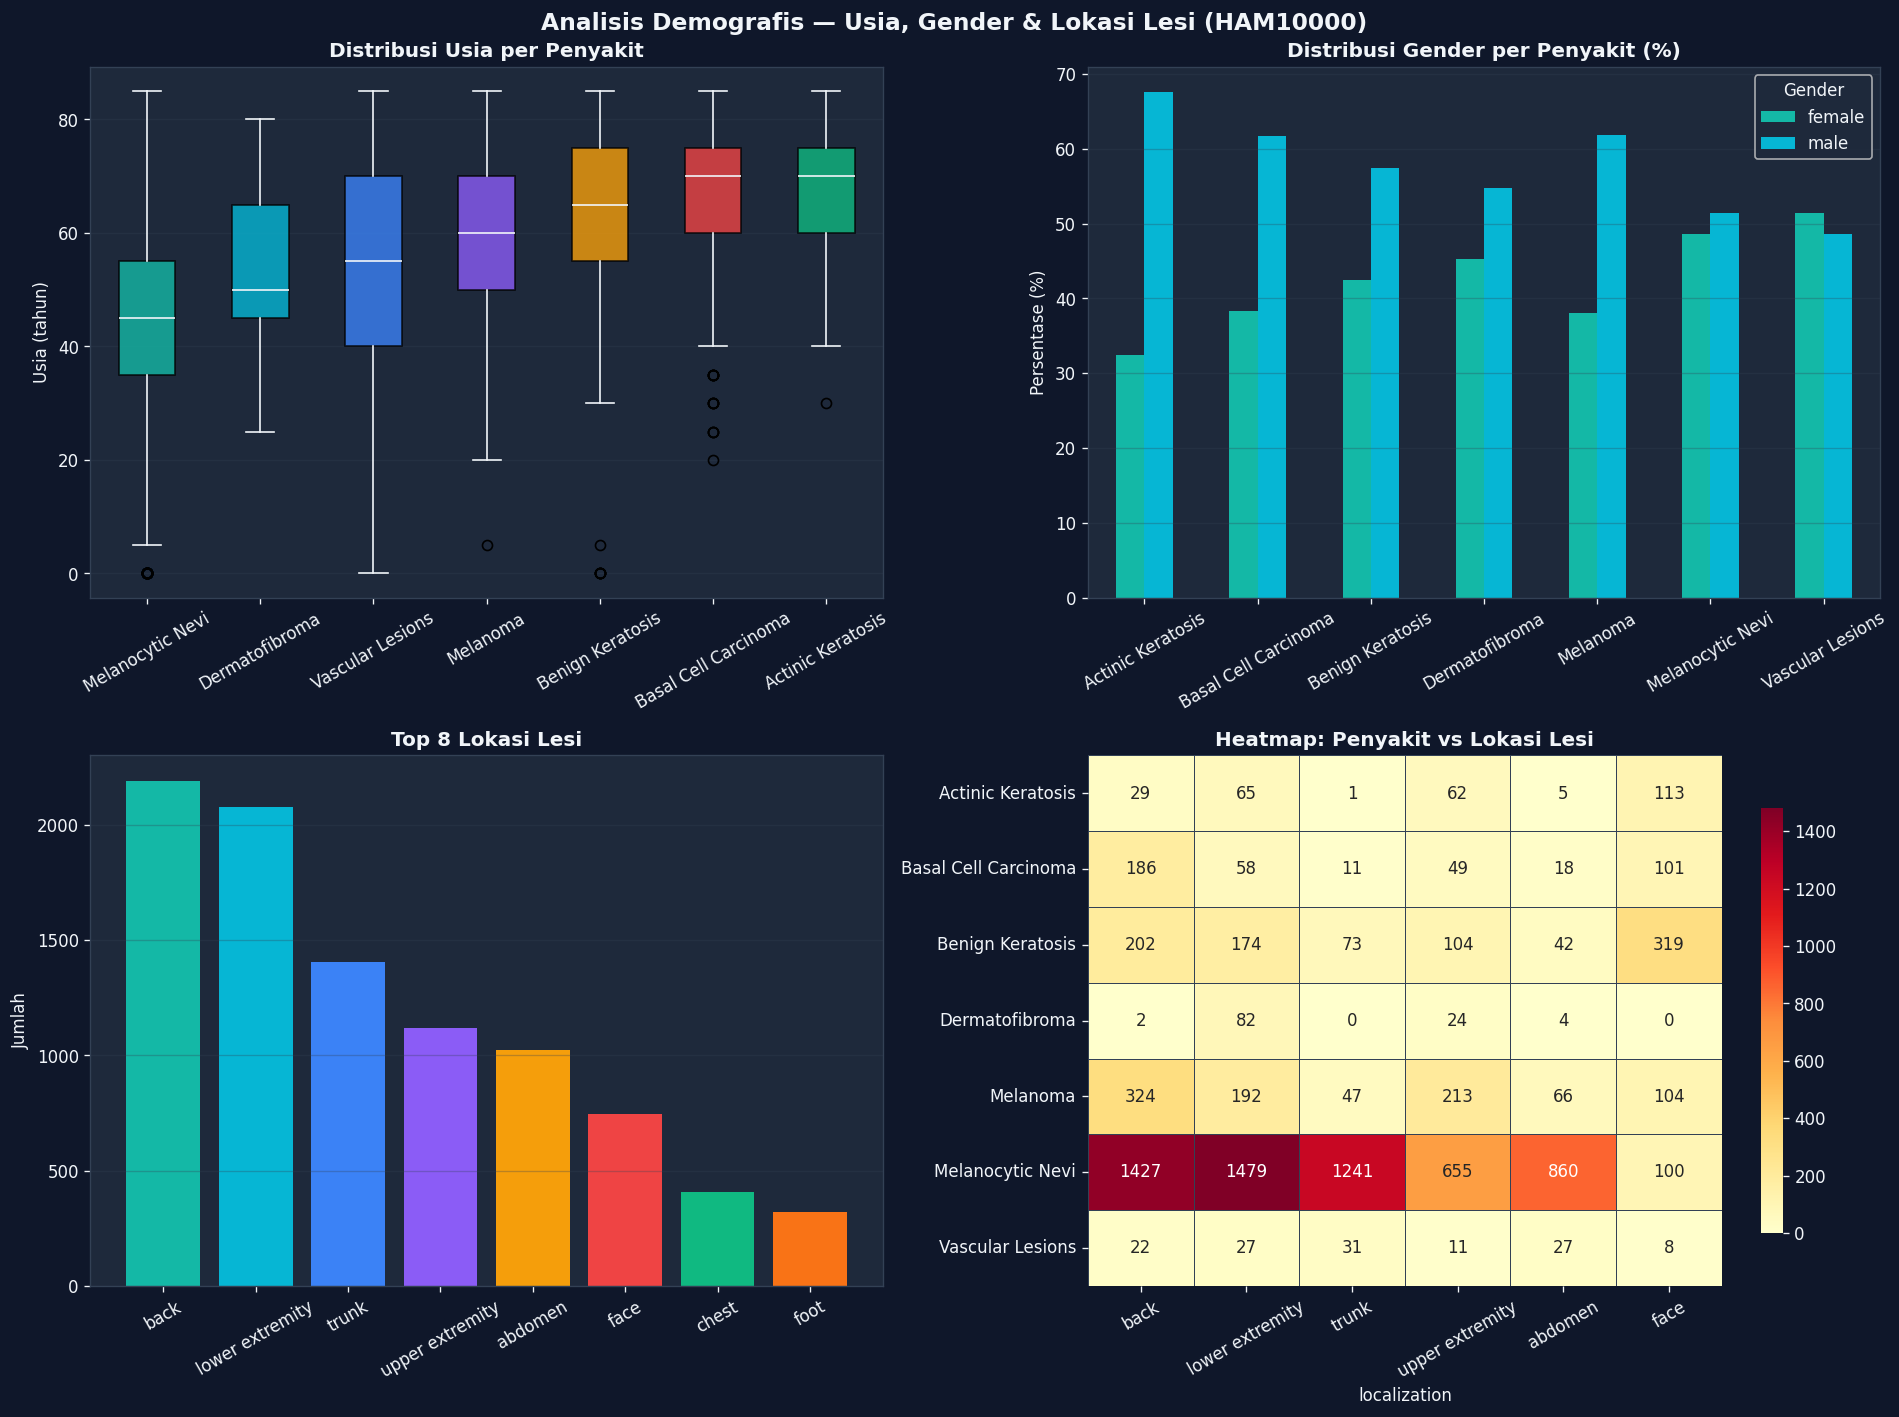

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Analisis Demografis — Usia, Gender & Lokasi Lesi (HAM10000)',
              fontsize=14, fontweight='bold', color=TEXT_CLR)

# 1. Boxplot usia per penyakit
order_dx = df_ham.groupby('dx')['age'].median().sort_values().index.tolist()
data_age = [df_ham[df_ham['dx'] == d]['age'].dropna().values for d in order_dx]
labels_age = [dx_map[d] for d in order_dx]
bp = axes[0,0].boxplot(data_age, labels=labels_age, patch_artist=True, notch=False)
for patch, color in zip(bp['boxes'], PALETTE):
    patch.set_facecolor(color); patch.set_alpha(0.8)
for el in ['whiskers','caps','medians']:
    for line in bp[el]: line.set_color(TEXT_CLR)
axes[0,0].set_title('Distribusi Usia per Penyakit', color=TEXT_CLR, fontweight='bold')
axes[0,0].set_ylabel('Usia (tahun)', color=TEXT_CLR)
axes[0,0].tick_params(axis='x', rotation=30)
axes[0,0].grid(axis='y', alpha=0.3)

# 2. Distribusi gender per penyakit
gender_cross = pd.crosstab(df_ham['dx'], df_ham['sex'], normalize='index') * 100
gender_cross.index = [dx_map[d] for d in gender_cross.index]
gender_cross.plot(kind='bar', ax=axes[0,1], color=[TEAL, CYAN], edgecolor='none')
axes[0,1].set_title('Distribusi Gender per Penyakit (%)', color=TEXT_CLR, fontweight='bold')
axes[0,1].set_ylabel('Persentase (%)', color=TEXT_CLR)
axes[0,1].tick_params(axis='x', rotation=30)
axes[0,1].legend(title='Gender')
axes[0,1].grid(axis='y', alpha=0.3)

# 3. Top 8 lokasi lesi
top_locs = df_ham['localization'].value_counts().head(8)
axes[1,0].bar(top_locs.index, top_locs.values, color=PALETTE[:8], edgecolor='none')
axes[1,0].set_title('Top 8 Lokasi Lesi', color=TEXT_CLR, fontweight='bold')
axes[1,0].set_ylabel('Jumlah', color=TEXT_CLR)
axes[1,0].tick_params(axis='x', rotation=30)
axes[1,0].grid(axis='y', alpha=0.3)

# 4. Heatmap penyakit vs lokasi
top_locs_list = df_ham['localization'].value_counts().head(6).index
cross_loc = pd.crosstab(df_ham['dx'], df_ham['localization'])[top_locs_list]
cross_loc.index = [dx_map[d] for d in cross_loc.index]
sns.heatmap(cross_loc, ax=axes[1,1], cmap='YlOrRd', annot=True, fmt='d',
            linewidths=0.5, linecolor='#334155', cbar_kws={'shrink':0.8})
axes[1,1].set_title('Heatmap: Penyakit vs Lokasi Lesi', color=TEXT_CLR, fontweight='bold')
axes[1,1].tick_params(axis='x', rotation=30)
axes[1,1].tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('eda_skin_03_demografis.png', bbox_inches='tight', facecolor=BG_DARK)
plt.show()

> **Insight PB4:** YA, usia dan lokasi tubuh sangat berpengaruh. Penyakit berbahaya (Basal Cell Carcinoma, Actinic Keratosis) muncul dominan pada usia 61-85 tahun. Punggung dan ekstremitas bawah adalah lokasi tersering — konsisten dengan paparan sinar matahari. **Usia dan lokasi lesi harus menjadi fitur tambahan dalam model skin detection**, bukan hanya gambar saja.

## 5. Leakage Analysis

In [10]:
dup_count = df_ham['is_duplicate_lesion'].sum()
total = len(df_ham)
print(f'Total gambar         : {total:,}')
print(f'Gambar dari lesi sama: {int(dup_count):,} ({dup_count/total*100:.1f}%)')
print(f'Gambar unik          : {total - int(dup_count):,}')

Total gambar         : 10,015
Gambar dari lesi sama: 4,501 (44.9%)
Gambar unik          : 5,514


## 6. Kesimpulan EDA Skin

| # | Temuan | Implikasi |
|---|--------|----------|
| 1 | 20.015 gambar dari 3 sumber, DermNet dominasi 94.2% | Data augmentasi untuk kelas minority |
| 2 | HAM10000: Nevi 67% data, Dermatofibroma hanya 1.1% | Imbalance ekstrem, wajib augmentasi |
| 3 | Penyakit berbahaya dominan pada usia 61-85 tahun | Usia sebagai fitur tambahan model |
| 4 | 45% gambar HAM10000 dari lesi yang sama | Wajib GroupShuffleSplit untuk hindari leakage |
| 5 | Punggung & ekstremitas bawah lokasi tersering | Lokasi tubuh sebagai fitur tambahan |

**Rekomendasi model:** Transfer Learning (MobileNetV2 / EfficientNetB0) + Data Augmentation untuk mengatasi imbalance.